In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group
from datetime import datetime

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
class ImageNetMixed(datasets.ImageNetSuperClass):
    selected_classes = [0, 100, 200]

In [6]:
dataset = datasets.construct("imagenet-butterfly")
# dataset = ImageNetMixed()

In [7]:
ds_train = dataset.create_subset(train_split=True)
ds_val = dataset.create_subset(train_split=False)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|██████████| 7800/7800 [00:00<00:00, 2347726.67it/s]


We have 300 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|█████████████| 300/300 [00:00<00:00, 481734.76it/s]


In [97]:
MODEL_NAME = "imagenet-vgg16-tv"

MAIN_LAYER = "avgpool"

In [98]:
teacher = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(teacher, dataset.selected_classes)

teacher.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [129]:
teacher

True

In [132]:
def ano():

    for layer in teacher.features.children():
        if isinstance(layer, torch.nn.ReLU):
            layer.inplace = False
    
    for layer in teacher.classifier.children():
        if isinstance(layer, torch.nn.ReLU):
            layer.inplace = False
ano()

In [133]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), pad

In [134]:

def last_layer_rewriting(model_name, rewriting):
    
    arr_logits = []
    arr_feats = []
    arr_targets = []
    
    model = models.get_trained_model(model_name)
    utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)
    model.to(device)
    
    if not rewriting:
        print(f"[rewriting={rewriting}] Return Original Model")
        return model
    
    with torch.no_grad():
        
        for count, (x, y) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            logits = model(x).cpu().numpy()
            arr_logits.append(logits)
            arr_targets.append(np.argmax(logits, axis=1))

#             if count > 1:
#                 break
    
    weights = model.__last_layer.weight.detach().cpu().numpy()
    
    acc_before, _ = metrics.accuracy(
        model,
        dataloader=datasets.build_dataloader(ds_val, shuffle=False),
        num_classes=dataset.num_classes,
        device=device,
    )

    normed_weights = weights / np.linalg.norm(weights, axis=1, keepdims=True)
    
    print(f"model_name={model_name}")
    if "vgg" in model_name:
        model.classifier[6] = torch.nn.Identity()
    elif "resnet" in model_name:
        model.fc = torch.nn.Identity()
    else:
        raise
    

    with torch.no_grad():
        
        for count, (x, y) in tqdm(enumerate(datasets.build_dataloader(ds_train, shuffle=False))):
            x = x.to(device)

            feat = model(x).cpu().numpy()
            arr_feats.append(feat)
#             if count > 1:
#                 break

    arr_logits = np.vstack(arr_logits)

    arr_feats = np.vstack(arr_feats)
    arr_targets = np.concatenate(arr_targets)
    
    
    arr_w = []
    arr_b = []
        
    for class_ix in tqdm(sorted(np.unique(arr_targets))):
        cond = arr_targets == class_ix
        arr_class_feats = arr_feats[cond, :]
        _, eigvecs = np.linalg.eigh(arr_class_feats.T @ arr_class_feats)
        pc1 = eigvecs[:, -1]
        pc1 = pc1 / np.linalg.norm(pc1)
        
        proj = np.mean(arr_class_feats @ pc1) 
        if proj < 0:
            pc1 = -pc1
            
        arr_w.append(pc1)
        
        bias = np.mean(arr_feats @ pc1 - arr_logits[:, class_ix])
        arr_b.append(bias)
        
    
    out_feats, in_feats = normed_weights.shape
    new_layer = torch.nn.Linear(out_features=out_feats, in_features=in_feats)
    new_layer.weight = torch.nn.Parameter(
        torch.from_numpy(np.stack(arr_w))
    )
    
    new_layer.bias = torch.nn.Parameter(
        torch.tensor(arr_b)
    )
    
    if "vgg" in model_name:
        model.classifier[6] = new_layer
    elif "resnet" in model_name:
        model.fc = new_layer
    else:
        raise

    new_layer.to(device)
    
    acc_after, _ = metrics.accuracy(
        model,
        dataloader=datasets.build_dataloader(ds_val, shuffle=False),
        num_classes=dataset.num_classes,
        device=device,
    )
    
    print(f"acc_before={acc_before}  : acc_after={acc_after}")
    
    return model
            


# teacher = last_layer_rewriting(MODEL_NAME, rewriting=True);

In [135]:
# teacher

In [136]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), pad

In [137]:
teacher_acc, _ = metrics.accuracy(
    teacher,
    dataloader=datasets.build_dataloader(ds_val, shuffle=False),
    num_classes=dataset.num_classes,
    device=device,
)
teacher_acc

0.9599999785423279

In [138]:
class AllOnePositiveEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        pass
    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        return (logits > 0)

    def __str__(self) -> str:
        
        return "ALlOnePositiveEvidence"
        
class RandomEvidence(attributors.LogitModifier):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes
        self.rng = torch.Generator()
        self.rng.manual_seed(1)
        
    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits = logits.clone()
        n, _ = logits.shape

        classes = torch.randint(0, self.num_classes, size=(n,), generator=self.rng)
        output = F.one_hot(classes, num_classes=self.num_classes).to(logits.device)
        return output * logits

    def __str__(self) -> str:
        return "RandomEvidence"

In [139]:
def make_attributor_for(
    model,
    input_statistics,
    gamma,
    epsilon,
):
    input_transform = transforms.Normalize(*input_statistics)

    low, high = input_transform(torch.tensor([[[[[0.0]]] * 3], [[[[1.0]]] * 3]]))

    if isinstance(model, models.resnet.resnet.ResNet):
        canonizers = [ResNetCanonizer()]
    else:
        canonizers = []

    print(f"Instantiating EpsilonGammaBox(gamma={gamma}, eps={epsilon})")

    composite = EpsilonGammaBox(low=low, high=high, canonizers=canonizers, gamma=gamma, epsilon=epsilon)

    attributor = Gradient(
        model=model, 
        composite=composite
    )


    return attributor


    
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []

    
    with make_attributor_for(model, dataset.input_statistics, gamma=gamma, epsilon=eps) as attributor:
        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad
                

                output_dimensions = act.shape[1:]
                # print("output.dimension", output_dimensions)
                # todo: check this with Gregoire again!
                ctx = torch.where(
                    act.abs() > 0, 
                    rel / act, 
                    0
                )

                np.testing.assert_allclose(
                    (act * ctx).detach().cpu().numpy(), 
                    (rel * (act.abs() > 0)).detach().cpu().numpy(),
                    atol=1e-6
                )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                if len(act.shape) == 2:
                    act = act[:, :, None, None]
                    ctx = ctx[:, :, None, None]

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


GAMMA = 0.25

def get_act_ctx(model, dataset, layer, gamma, eps=1e-6, verbose=False):

    # logit_modifier = attributors.WinningClassEvidence(num_classes=len(dataset.selected_classes))
    logit_modifier = attributors.WinningClassOneHotEvidence(num_classes=len(dataset.selected_classes))
    # logit_modifier = RandomEvidence(num_classes=len(dataset.selected_classes))

    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        gamma=gamma,
        eps=eps,
        verbose=verbose,
    )


_arr_act, _arr_ctx = get_act_ctx(
    teacher,
    dataset,
    gamma=GAMMA,
    layer=MAIN_LAYER, 
    verbose=False
)

Instantiating EpsilonGammaBox(gamma=0.25, eps=1e-06)


100%|████████████████████████████████████████████████████████| 122/122 [01:23<00:00,  1.46it/s]


In [140]:
dataset.selected_classes

[321, 322, 323, 324, 325, 326]

In [141]:
print("norm ration", np.mean(np.linalg.norm(_arr_ctx) / np.linalg.norm(_arr_act)))

norm ration 8.498449e-05


ratio 7.2219453e-09


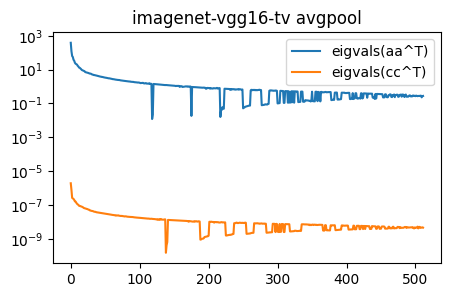

In [142]:
def viz_eigvals():
    
    cov = _arr_act.T @ _arr_act 
    cov /= _arr_act.shape[0]

    pca_eigvals = np.linalg.eigvals(cov)
    # pca_eigvals /= np.max(pca_eigvals)


    
    gcov = _arr_ctx.T @ _arr_ctx
    gcov /= _arr_act.shape[0]

    grad_eigvals = np.linalg.eigvals(gcov)
    # grad_eigvals /= np.max(grad_eigvals)


    plt.figure(figsize=(5, 3))
    plt.title(f"{MODEL_NAME} {MAIN_LAYER}")
    plt.plot(pca_eigvals, label="eigvals(aa^T)")
    plt.plot(grad_eigvals, label="eigvals(cc^T)")
    ratio = np.abs(grad_eigvals).sum() / pca_eigvals.sum()
    print("ratio", ratio)
    plt.legend()
    plt.yscale("log")
    
viz_eigvals()

In [143]:
# from torch.nn.utils.parametrizations import orthogonal

# def learn_prca_opt(
#     model, location1,  k,
#     seed=1, epochs=25,
#     verbose=False,
# ):

#     rng = torch.Generator()
#     rng.manual_seed(seed)

#     _, d = _arr_act.shape

#     _, eigvecs = np.linalg.eigh(_arr_act.T @ _arr_act)
    
#     U = eigvecs[:, ::-1]
#     U = U[:, :k].copy()
#     w = torch.nn.Linear(k ,d, bias=False)

#     w.weight = torch.nn.Parameter(torch.from_numpy(U.T).float())
    
#     layer = orthogonal(w).to(device)
    
        
#     A = torch.from_numpy(_arr_act).to(device)
    
#     C = torch.from_numpy(_arr_ctx).to(device)

#     print(A.shape, C.shape)
    
#     dl_train = datasets.build_dataloader(ds_train, shuffle=False)

#     dl_val = datasets.build_dataloader(ds_val, shuffle=False)
#     acc = 0

#     opt =  torch.optim.Adam(layer.parameters(), lr=1e-3)
#     alpha = 1
#     pgb = tqdm(range(epochs), disable=not verbose)
#     for epoch in tqdm(pgb):
#         opt.zero_grad()
        
#         U = layer.weight.T 
            
#         A_recon = A @ U @ U.T
#         diff = A_recon - A

#         term_recon = torch.linalg.norm(diff, dim=1) ** 2

#         rel = (A*C)
#         A_on_U = A@U @ U.T
#         C_on_U = C
#         proj_rel = (A_on_U * C_on_U)
#         term_rel = ((rel - proj_rel)**2).sum(dim=1)

#         # assert term_recon.shape == term_rel.shape
#         loss = (0*term_recon + alpha * term_rel).mean()
#         loss.backward()
            
#         opt.step()

#         val_acc = compute_accuracy_with_Uk(
#             model, location1, U.data.detach().cpu().numpy(), dataset, dl_val
#         )
#         # with torch.no_grad():
#             # U = layer.weight.T
            
#             # diff = A@ U @U.T - A
#             # recon = torch.linalg.norm(diff, axis=1).mean()
#             # normed_J = G / torch.linalg.norm(G, dim=2, keepdim=True)
#             # normed_diff = diff / torch.linalg.norm(diff, dim=1, keepdim=True)
            
#             # cosine = torch.bmm(normed_J, normed_diff.unsqueeze(2)).abs().mean()
            
# #         train_acc = compute_accuracy_with_Uk(
# #             model, location1, U.data.detach().cpu().numpy(), dataset, dl_train
# #         )
#         train_acc = 0
#         pgb.set_description(
#             f"k={k}: loss={loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
#         )

#     return U.detach().cpu().numpy()
    
# def ano():
#     U = learn_prca_opt(
#         teacher,
#         location1=MAIN_LAYER,
#         k=4, 
#         verbose=True,
#     )
#     d, k = U.shape    
#     np.testing.assert_allclose(
#         U.T@U,
#         np.eye(k),
#         atol=1e-4
#     )

#     dl = datasets.build_dataloader(ds_val, shuffle=False)

#     acc_U = compute_accuracy_with_Uk(teacher, layer=MAIN_LAYER, Uk=U, dataset=dataset, dl=dl)
#     print(f"acc(U)={acc_U:.4f}") 
# ano()

In [162]:
def solve_pca(arr_act, arr_ctx):
    _, pca_eigvecs = np.linalg.eigh(arr_act.T @ arr_act)
    U = np.flip(pca_eigvecs, axis=1).copy()
    return U.copy()

def solve_pcaprca(arr_act, arr_ctx, alpha):
    cov = arr_act.T @ arr_act
    max_eigval_act = np.linalg.eigvalsh(arr_act.T @ arr_act).max()
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
    max_eigval_ctx = np.linalg.eigvalsh(ccov).max()

    assert alpha >= 0
    eigvals, eigvecs = np.linalg.eigh(
        cov / max_eigval_act + (alpha / max_eigval_ctx) * ccov
    )

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()

def solve_prcascale(arr_act, arr_ctx):
    scale = np.linalg.norm(arr_ctx, axis=1, keepdims=True) * np.linalg.norm(arr_act, axis=1, keepdims=True)
    arr_act = arr_act * scale
    
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(
        ccov
    )

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()

def solve_prcascale_with_act(arr_act, arr_ctx):
    scale = np.linalg.norm(arr_act, axis=1, keepdims=True)
    arr_act = arr_act * scale
    
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(
        ccov
    )

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()

def solve_prca(arr_act, arr_ctx):
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(
        ccov
    )

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-np.abs(eigvals))

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()

def solve_prcaraw(arr_act, arr_ctx):
    ccov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act

    eigvals, eigvecs = np.linalg.eigh(
        ccov
    )

    assert eigvals.shape == (arr_act.shape[1], )
    
    indices = np.argsort(-eigvals)

    U = np.copy(eigvecs[:, indices])
    
    return U.copy()


def solve(method, arr_act, arr_ctx):
    if method == "pca":
        return solve_pca(arr_act, arr_ctx)
    elif method == "prca":
        return solve_prca(arr_act, arr_ctx)
    elif method == "prcaraw":
        return solve_prcaraw(arr_act, arr_ctx)
    elif method == "prcascale":
        return solve_prcascale(arr_act, arr_ctx)
    elif method == "prcascale-with-act":
        return solve_prcascale_with_act(arr_act, arr_ctx)
    elif method == "pcaprcaopt":
        return solve_pcaprca(arr_act, arr_ctx, alpha=7.340563e-05)
    elif method == "pcaprca1e-1":
        return solve_pcaprca(arr_act, arr_ctx, alpha=1e-1)
    elif method == "pcaprca1e-0":
        return solve_pcaprca(arr_act, arr_ctx, alpha=1e-0)
    elif method == "pcaprca1e1":
        return solve_pcaprca(arr_act, arr_ctx, alpha=1e1)
    elif method == "pcaprca1e2":
        return solve_pcaprca(arr_act, arr_ctx, alpha=1e2)
    elif method == "pcaprca1e3":
        return solve_pcaprca(arr_act, arr_ctx, alpha=1e3)
    # elif method == "pcaprca0.01":
    #     return solve_pcaprca(arr_act, arr_ctx, alpha=0.01)
    # elif method == "pcaprca0.05":
    #     return solve_pcaprca(arr_act, arr_ctx, alpha=0.05)
    # elif method == "pcaprca0.1":
    #     return solve_pcaprca(arr_act, arr_ctx, alpha=0.1)    
    else:
        raise ValueError(f"{method} doesn't exist!")

def ano():

    for method in [
        "prcascale",
        "pcaprcaopt",
                "prcascale-with-act",

        "pcaprca1e3",
        
        "pcaprca1e2",
        # "pcaprca0.01", "pcaprca0.05", 
        # "pcaprca0.1", "prca", "pca"
    ]:
        solve(method, _arr_act, _arr_ctx)
    print(">>>>>>>")
ano()

>>>>>>>


In [145]:
def fh_low_rank(U):
    d, k = U.shape

    assert k <= d

    UUT = U @ U.T 
    assert UUT.shape == (d, d)

    UUT = torch.from_numpy(UUT).float().unsqueeze(2).unsqueeze(3).to(device)
    
    def do(module, inp, out):
        inp, = inp

        shape = out.shape
        if len(shape) == 2:
           out = out.unsqueeze(2).unsqueeze(3)
        
        out2 = F.conv2d(out, UUT)

        if k == d and False:
            np.testing.assert_allclose(
                out.detach().cpu().numpy(), out2.detach().cpu().numpy(),
                atol=1e-3
            )

        out2 = out2.reshape(shape)
        
        return out2

    return UUT, do 

def compute_accuracy_with_Uk(
    model, layer, Uk, dataset, dl
):
    module = utils.interceptor.get_module(model, layer)

    UUT, hook_func = fh_low_rank(Uk)
    hook = module.register_forward_hook(hook_func)

    try:
        acc, _ = metrics.accuracy(
                        model,
                        dataloader=dl,
                        num_classes=dataset.num_classes,
                        device=device,
                )
        
    finally:
        hook.remove()
        del UUT
    return acc  


In [146]:
teacher

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU()
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (17): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), pad

In [147]:
MODEL_NAME, MAIN_LAYER

('imagenet-vgg16-tv', 'avgpool')

['pca', 'prca', 'pcaprca1e-1', 'pcaprca1e-0', 'pcaprca1e1']


  0%|                                                                    | 0/8 [00:00<?, ?it/s]

basis_name=pca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=prca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-1; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-0; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e1; layer=avgpool; model_name=imagenet-vgg16-tv


 12%|███████▌                                                    | 1/8 [00:14<01:42, 14.71s/it]

basis_name=pca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=prca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-1; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-0; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e1; layer=avgpool; model_name=imagenet-vgg16-tv


...

basis_name=pca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=prca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-1; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-0; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e1; layer=avgpool; model_name=imagenet-vgg16-tv


 88%|████████████████████████████████████████████████████▌       | 7/8 [01:40<00:14, 14.40s/it]

basis_name=pca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=prca; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-1; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e-0; layer=avgpool; model_name=imagenet-vgg16-tv
basis_name=pcaprca1e1; layer=avgpool; model_name=imagenet-vgg16-tv


100%|████████████████████████████████████████████████████████████| 8/8 [01:55<00:00, 14.43s/it]


,layer,k,basis_name,acc_val
0,avgpool,1,pca,0.133333
1,avgpool,1,prca,0.166667
2,avgpool,1,pcaprca1e-1,0.153333
3,avgpool,1,pcaprca1e-0,0.166667
4,avgpool,1,pcaprca1e1,0.166667
5,avgpool,2,pca,0.440000
6,avgpool,2,prca,0.176667
7,avgpool,2,pcaprca1e-1,0.423333
8,avgpool,2,pcaprca1e-0,0.403333
9,avgpool,2,pcaprca1e1,0.183333


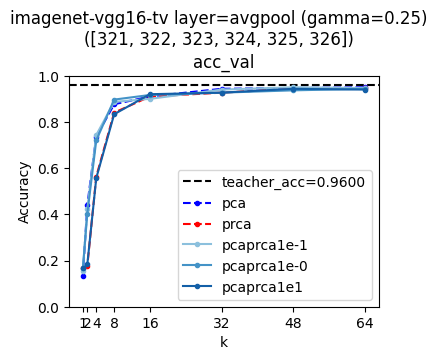

In [163]:
import matplotlib as mpl


def compute_accuracy_of_basis_at_k(
    model, dataset, layer, 
    arr_ks,
    arr_bases,
):
    dl_val = datasets.build_dataloader(ds_val, shuffle=False)
    dl_train = datasets.build_dataloader(ds_train, shuffle=False)    
    
    rows = []
    print(arr_bases)
    for k in tqdm(arr_ks):
        for basis_name in arr_bases:
            Uk = estimate_basis(
                layer=layer,
                basis_name=basis_name, 
                k=k
            )
            acc_val = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_val)
#             acc_train = compute_accuracy_with_Uk(model, layer, Uk, dataset, dl_train)

            rows.append(
                    dict(
                        layer=layer, k=k, 
                        basis_name=basis_name,
                        acc_val=acc_val,
#                         acc_train=acc_train
                    )
            )
    

    df = pd.DataFrame(rows)

    return df



def estimate_basis(layer, basis_name, k):
    print(f"basis_name={basis_name}; layer={MAIN_LAYER}; model_name={MODEL_NAME}")

    U = solve(basis_name, _arr_act, _arr_ctx)[:, :k]
    return U
    
def estimate_rank_k_accuracies(
    model, dataset, layer,
    arr_bases=[
        "pca",
        "prca",
        # "prcaraw",
        # "prcascale-with-act",

        # "pcaprcaopt",
        "pcaprca1e-1",
        "pcaprca1e-0",
        "pcaprca1e1",
        
    ],
    arr_ks=[1,2, 4, 8, 16, 32, 48, 64],
):

    colors = mpl.cm.Blues
    nbases = len(arr_bases)

    df = compute_accuracy_of_basis_at_k(
        model, dataset, layer, 
        arr_bases=arr_bases,
        arr_ks=arr_ks
    )

    torch.cuda.empty_cache()

    def alias(name):
        return name
        if name == "pca":
            return "PCA"
        elif "prcaopt:" in name:
            _, slug = name.split(":")
            return f"PCA-LH:{slug}"
        else:
            raise
            
    def ls(name):
        if name in  ["pca", "prca"]:
            return "--"
        else:
            return "-"

    def color(name):
        if name == "pca":
            return "blue"
        elif name == "prca":
            return "red"
        else:
            return None
            

    cols = [
#         "acc_train", 
        "acc_val"
    ]
    ncols = len(cols)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(f"{MODEL_NAME} layer={layer} (gamma={GAMMA})\n({dataset.selected_classes})", y=1.1)

    for cix, col in enumerate(cols):
        plt.subplot(1, ncols, cix+1)
        plt.title(col)
        plt.axhline(teacher_acc, ls="--", color="black", label=f"teacher_acc={teacher_acc:.4f}")
        for nix, name in enumerate(df.basis_name.unique()):
            _df = df[df.basis_name == name]
            
            plt.plot(
                _df.k, 
                _df[col],
                label=alias(name),
                ls=ls(name),
                marker=".",
                color=color(name) if name in ["pca", "prca"] else colors((nix+0.1)/nbases) 
            )
    
        plt.ylim([0, 1])
        plt.legend()
        plt.ylabel("Accuracy"); plt.xlabel("k")
        plt.xticks(df.k.unique())
    
    return df
    
estimate_rank_k_accuracies(model=teacher, dataset=dataset, layer=MAIN_LAYER)

In [149]:
print(f"Finished at {datetime.now()}")

Finished at 2024-05-08 10:29:56.293441


In [150]:
teacher.classifier[0].weight.shape

torch.Size([4096, 25088])

In [151]:
_arr_act.shape

(156000, 512)

In [152]:
_arr_act.max()

64.97937